<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/02_machine_learning/evaluation/experiment_classification_metrics_imbalance_accuracy_precision_recall_roc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# LEVEL 1: ACCURACY FAILURE CASE
# ============================================

import numpy as np
from sklearn.metrics import accuracy_score

# 95% normal, 5% fraud
y_true = np.array([0]*95 + [1]*5)

# Model predicts all normal
y_pred = np.array([0]*100)

accuracy = accuracy_score(y_true, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.95


In [2]:
# ============================================
# LEVEL 2: CORE METRICS
# ============================================

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.0
Recall: 0.0
F1 Score: 0.0


In [4]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[95  0]
 [ 5  0]]


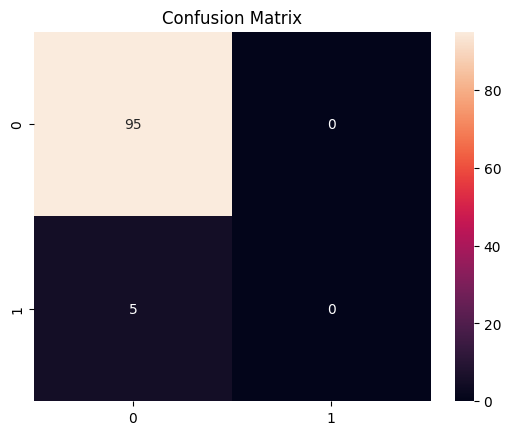

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

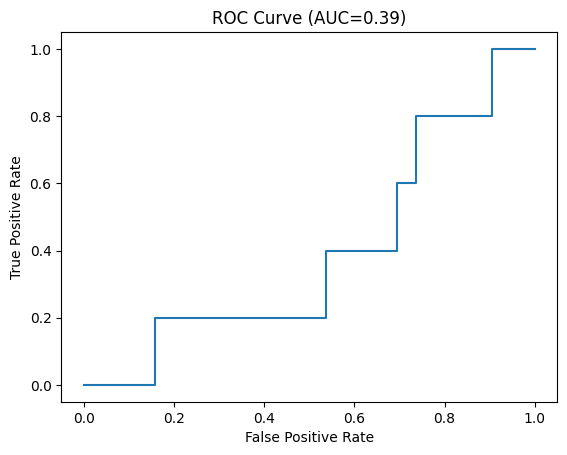

In [6]:
from sklearn.metrics import roc_curve, auc

# fake probabilities
y_scores = np.random.rand(100)

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC={roc_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier

# Generate dummy data for demonstration
X = np.random.rand(100, 10)  # 100 samples, 10 features
y = np.array([0]*95 + [1]*5) # Using the same distribution as y_true

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Define a simple dummy model for demonstration
class DummyModel:
    def predict(self, X):
        # For simplicity, let's make it predict all 0s, similar to the initial y_pred
        return np.zeros(len(X), dtype=int)

dummy_model = DummyModel()

# Create a dictionary of models (in a real scenario, this would contain trained models)
models = {
    "Dummy Model": dummy_model
}

print("Dummy data and model created.")

Dummy data and model created.


In [10]:
from sklearn.metrics import classification_report

for name, model in models.items():
    preds = model.predict(X_test)

    print(f"\n{name} Report:\n")
    print(classification_report(y_test, preds))


Dummy Model Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        29
           1       0.00      0.00      0.00         1

    accuracy                           0.97        30
   macro avg       0.48      0.50      0.49        30
weighted avg       0.93      0.97      0.95        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
